## Step 0: Get your packages in order.

In [ ]:
!pip install SimpleITK # This is a special library for visualising medical images.
!pip install medpy # This is a special library for medical image processing and metric computation.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 21.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.3/156.3 kB 4.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for medpy: filename=MedPy-0.5.2-py3-none-any.whl size=224710 sha256=ebdd468c53f36b0e54127976061ef9ae8ff8853603b1a274b664154ffbf05d1e
  Stored in directory: /root/.cache/pip/wheels/89/5a/f8/b3def53b9c2133d2f8698ea2173bb5df63bd8e761ce8e9aec9
Successfully built medpy


In [ ]:
import pandas as pd
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import sklearn as skl
import albumentations as A
from skimage.transform import resize
import SimpleITK as sitk
import tensorflow as tf
from tensorflow import keras
import medpy
import cv2
from medpy.metric.binary import hd, hd95, dc
from keras import layers, Model
from keras.utils import Sequence
from keras.callbacks import EarlyStopping, CSVLogger, ModelCheckpoint

In [ ]:
# Define the results directory

results_dir = '/content/drive/MyDrive/CSE602_Project_Results'
run_num = 8

# 1. Download and Load the Training, Test and Validation Datasets

Data source: [BOston Neonatal Brain Injury Data](https://zenodo.org/records/10602767)


### *A Note on the Training Data* ###

The data consists of a special type of preprocessed MRI images, known as ADC maps.

*ADC: Apparent Diffusion Coefficient*
- It is a measure of the magnitude of diffusion (or movement) of water molecules across brain tissues.

- This molecular movement can be restricted due to structural damage in the brain, such as tumours or lesions.

- Areas where this happens tend to appear noticeably darker than surrounding areas on MRI images.

- These darker areas can help doctors to determine where these lesions or tumours could be located on the brain.

The ADC maps in the dataset have been categorised into three groups.

The first group contains raw, unedited, unprocessed images.

The second group comprises ADC maps that have undergone Z-score normalisation. This has been done to account for the fact that, under healthy conditions, different areas of the brain have different movement patterns of water molecules.

 So, Z-score normalisation is required to ensure that the movement of water molecules is compared across brain regions, according to each specific region's healthy baseline for molecular movement.

 The third group comprises binary masks of the images in which the brain lesions have been manually annotated by trained physicians.

 More information can be found on these pages:

 [Bao et al., 2023](https://www.biorxiv.org/content/10.1101/2023.06.30.546841v1.full)

 [Radiopaedia - Apparent Diffusion Coefficient](https://radiopaedia.org/articles/apparent-diffusion-coefficient-1)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!unzip -q /content/drive/MyDrive/CSE602_Project_Data/train_data.zip
!unzip -q /content/drive/MyDrive/CSE602_Project_Data/val_data.zip
!unzip -q -P 'i3labhie2023' /content/drive/MyDrive/CSE602_Project_Data/test_data.zip

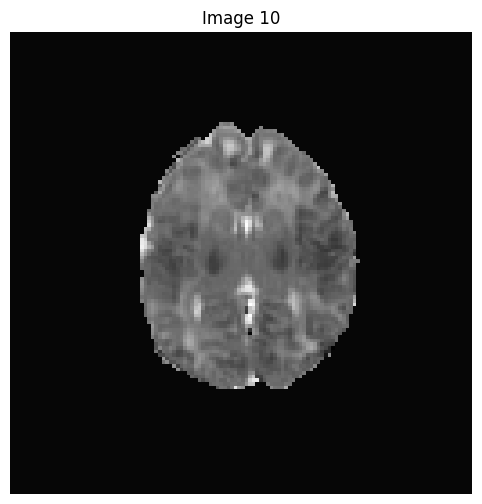

(128, 128, 23)


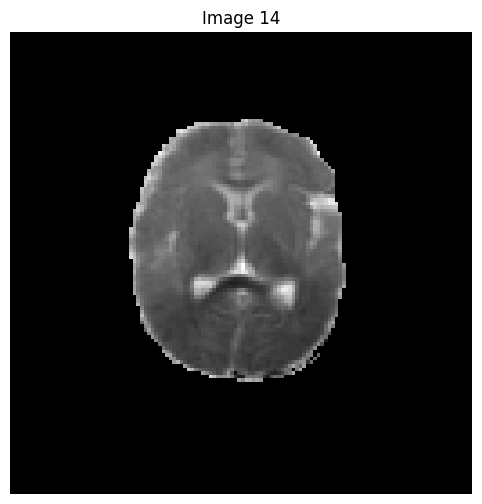

(128, 128, 23)


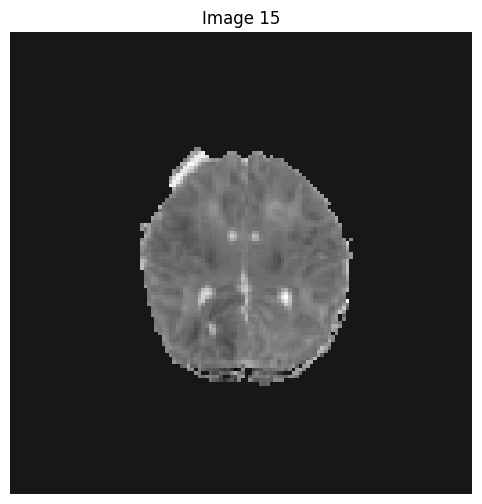

(128, 128, 23)


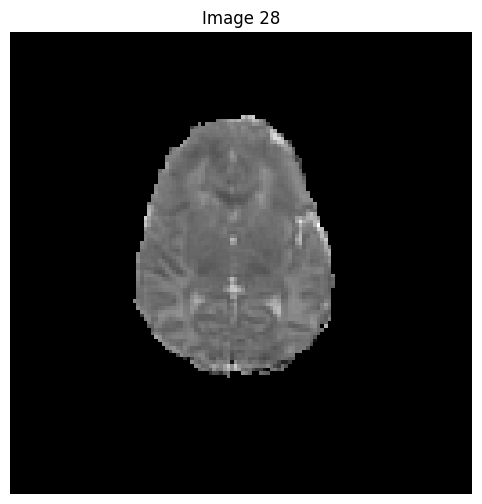

(128, 128, 23)


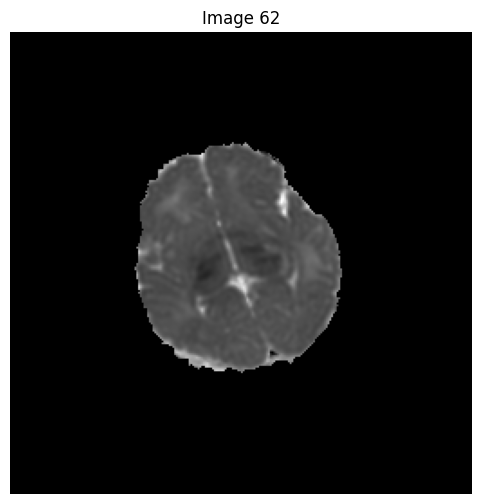

(256, 256, 19)


In [ ]:
#Some basic EDA; we read in and visualise the first five raw ADC maps to get a glimpse of the data we'll be dealing with.

train_dir = '/content/BONBID2023_Train'

for i in [10, 14, 15, 28, 62]:
  train_image = sitk.ReadImage(f"{train_dir}/1ADC_ss/MGHNICU_0{i}-VISIT_01-ADC_ss.mha")
  train_array = sitk.GetArrayFromImage(train_image)
  mid_slice = train_array.shape[0] // 2

  plt.figure(figsize=(8, 6))
  plt.imshow(train_array[mid_slice, :, :], cmap = 'gray')
  plt.title(f"Image {i}")
  plt.axis('off')
  plt.show()
  print(train_image.GetSize())

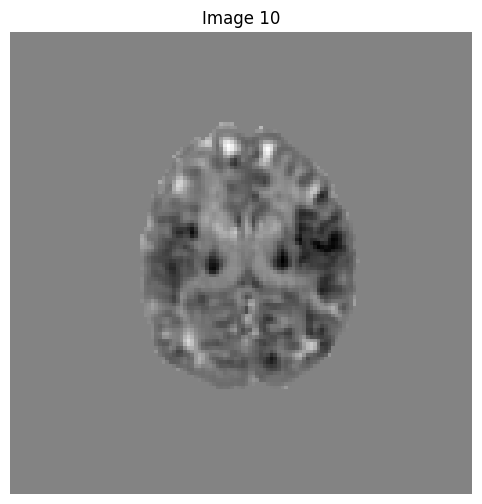

(128, 128, 23)


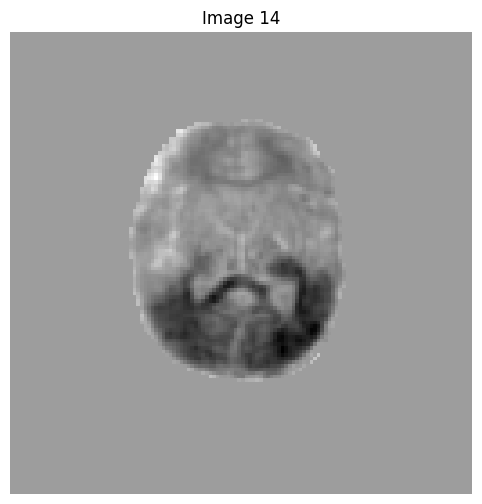

(128, 128, 23)


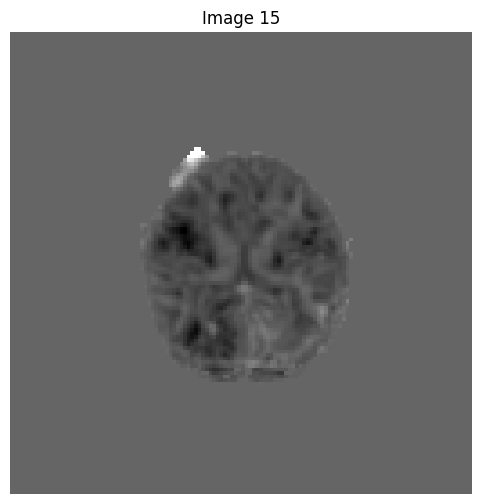

(128, 128, 23)


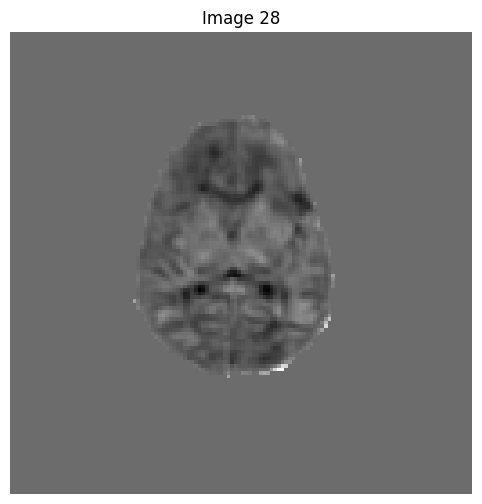

(128, 128, 23)


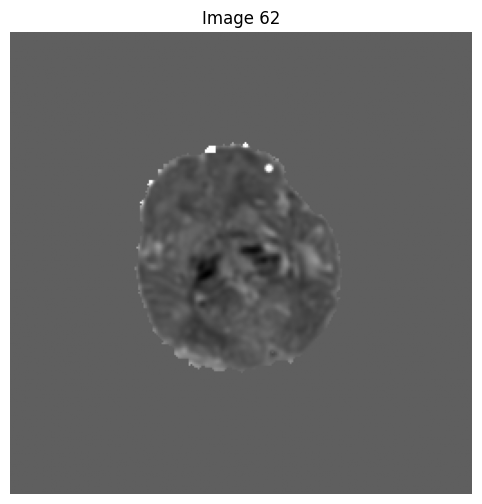

(256, 256, 19)


In [ ]:
# We do the same for the Z-score normalised ADC maps...

for i in [10, 14, 15, 28, 62]:
  train_image = sitk.ReadImage(f"{train_dir}/2Z_ADC/Zmap_MGHNICU_0{i}-VISIT_01-ADC_smooth2mm_clipped10.mha")
  train_array = sitk.GetArrayFromImage(train_image)
  mid_slice = train_array.shape[0] // 2

  plt.figure(figsize=(8, 6))
  plt.imshow(train_array[mid_slice, :, :], cmap = 'gray')
  plt.title(f"Image {i}")
  plt.axis('off')
  plt.show()
  print(train_image.GetSize())

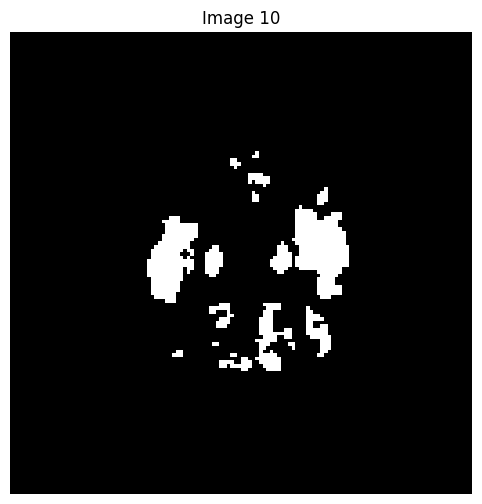

(128, 128, 23)


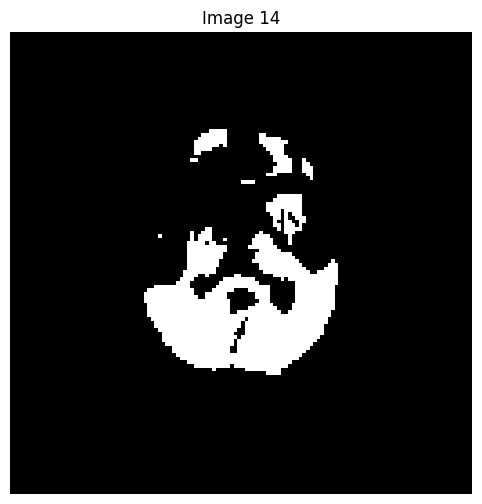

(128, 128, 23)


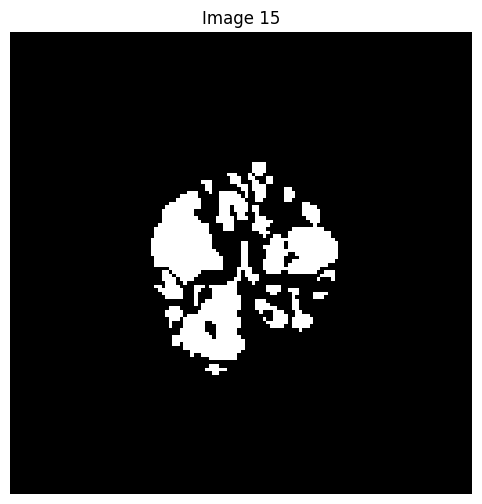

(128, 128, 23)


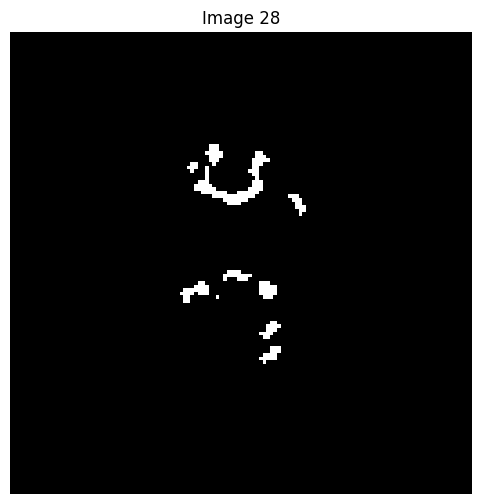

(128, 128, 23)


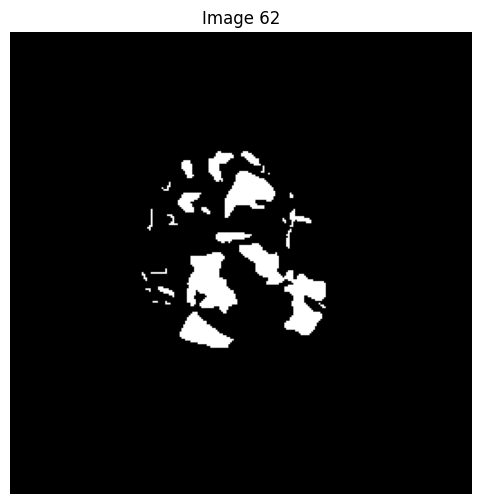

(256, 256, 19)


In [ ]:
# ...and for the binary image masks with brain lesions annotated by experts.

for i in [10, 14, 15, 28, 62]:
  train_image = sitk.ReadImage(f"{train_dir}/3LABEL/MGHNICU_0{i}-VISIT_01_lesion.mha")
  train_array = sitk.GetArrayFromImage(train_image)
  mid_slice = train_array.shape[0] // 2

  plt.figure(figsize=(8, 6))
  plt.imshow(train_array[mid_slice, :, :], cmap = 'gray')
  plt.title(f"Image {i}")
  plt.axis('off')
  plt.show()
  print(train_image.GetSize())

##2. Read in and Preprocess the Training and Validation Data

In order to build a model that uses multimodal data, using the ADC and ZADC maps as two separate modalities, we need to stack the ADC and ZADC maps to obtain the final training, test and validation datasets.

In [ ]:
# We define a helper function to load in, resize and stack the data.

def load_and_resize_images(directory_path, is_mask=False, target_shape=(23, 128, 128)):
    image_list = []
    filepaths = sorted(glob.glob(os.path.join(directory_path, '*.*')))

    for filepath in filepaths:
        sitk_img = sitk.ReadImage(filepath)
        img_array = sitk.GetArrayFromImage(sitk_img)

        if img_array.shape != target_shape:
            if is_mask:
                img_array = resize(img_array, target_shape,
                                   order=0, preserve_range=True, anti_aliasing=False)
            else:
                img_array = resize(img_array, target_shape,
                                   order=1, preserve_range=True, anti_aliasing=True)

        image_list.append(img_array)

    return np.concatenate(image_list, axis=0)

In [ ]:
# We use our helper function to load in and prepare the training, test and validation datasets.

adc_train = load_and_resize_images('/content/BONBID2023_Train/1ADC_ss/', is_mask=False)
zadc_train = load_and_resize_images('/content/BONBID2023_Train/2Z_ADC/', is_mask=False)

y_train = load_and_resize_images('/content/BONBID2023_Train/3LABEL/', is_mask=True)

X_train = np.stack((adc_train, zadc_train), axis=-1)
y_train = np.expand_dims(y_train, axis=-1)


In [ ]:
adc_test = load_and_resize_images('/content/BONBID2023_Test/1ADC_ss/', is_mask=False)
zadc_test = load_and_resize_images('/content/BONBID2023_Test/2Z_ADC/', is_mask=False)

y_test = load_and_resize_images('/content/BONBID2023_Test/3LABEL/', is_mask=True)

X_test = np.stack((adc_test, zadc_test), axis=-1)
y_test = np.expand_dims(y_test, axis=-1)

In [ ]:
adc_val = load_and_resize_images('/content/1ADC_ss/', is_mask=False)
zadc_val = load_and_resize_images('/content/2Z_ADC/', is_mask=False)

y_val = load_and_resize_images('/content/3LABEL/', is_mask=True)

X_val = np.stack((adc_val, zadc_val), axis=-1)
y_val = np.expand_dims(y_val, axis=-1)

In [ ]:
print(X_train.shape)
print(y_train.shape)

(1955, 128, 128, 2)
(1955, 128, 128, 1)


In [ ]:
print(X_test.shape)
print(y_test.shape)

(1012, 128, 128, 2)
(1012, 128, 128, 1)


In [ ]:
print(X_val.shape)
print(y_val.shape)

(92, 128, 128, 2)
(92, 128, 128, 1)


##3. Build and Train the Model

The chosen model architecture is the [2.5D Transformer Backbone U-Net Model](https://www.mdpi.com/2076-3425/15/8/778#:~:text=To%20evaluate%20the%20effectiveness%20of,diagnostic%20tools%20in%20clinical%20settings.).


This architecture has been chosen as it has achieved a Dice score of 0.8153 while segmented brain lesions in stroke patients.


The detailed rationale for this choice of architecture may be found in the explanatory project idea presentation which has been uploaded to this repository.


The following model architecture is a baseline architecture to implement this model. The model is under active development and parameters are being edited based on the model's performance on successive training and validation cycles.

In [ ]:
def transformer_block(x, num_heads = 4, key_dim = 128, mlp_dim = 256, dropout = 0.1):
    attn_out = layers.MultiHeadAttention(num_heads=num_heads, key_dim=key_dim)(x, x)
    attn_out = layers.Dropout(dropout)(attn_out)
    x = layers.Add()([x, attn_out])
    x = layers.LayerNormalization(epsilon=1e-6)(x)

    mlp_out = layers.Dense(mlp_dim, activation='gelu')(x)
    mlp_out = layers.Dense(x.shape[-1])(mlp_out)
    mlp_out = layers.Dropout(dropout)(mlp_out)
    x = layers.Add()([x, mlp_out])
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    return x

In [ ]:
def build_2_5d_transunet(input_shape=(128, 128, 2), num_classes = 1):
    inputs = layers.Input(shape=input_shape)

    c1 = layers.Conv2D(128, 3, padding='same')(inputs)
    c1 = layers.BatchNormalization()(c1)
    c1 = layers.Activation('relu')(c1)

    c1 = layers.Conv2D(128, 3, padding='same')(c1)
    c1 = layers.BatchNormalization()(c1)
    c1 = layers.Activation('relu')(c1)
    p1 = layers.MaxPooling2D()(c1)

    c2 = layers.Conv2D(128, 3, padding='same')(p1)
    c2 = layers.BatchNormalization()(c2)
    c2 = layers.Activation('relu')(c2)

    c2 = layers.Conv2D(128, 3, padding='same')(c2)
    c2 = layers.BatchNormalization()(c2)
    c2 = layers.Activation('relu')(c2)
    p2 = layers.MaxPooling2D()(c2)

    shape = p2.shape
    patch_dim = shape[-1]
    flattened = layers.Reshape((shape[1] * shape[2], patch_dim))(p2)

    t1 = transformer_block(flattened)
    t2 = transformer_block(t1)

    t_feat = layers.Reshape((shape[1], shape[2], patch_dim))(t2)
    t_feat = layers.Conv2D(128, 3, padding='same', activation='relu')(t_feat)

    u_block1 = layers.Conv2DTranspose(128, 2, strides=2, padding='same')(t_feat)
    u_block1 = layers.concatenate([u_block1, c2])

    conv_block1 = layers.Conv2D(128, 3, padding='same')(u_block1)
    conv_block1 = layers.BatchNormalization()(conv_block1)
    conv_block1 = layers.Activation('relu')(conv_block1)

    conv_block1 = layers.Conv2D(128, 3, padding='same')(conv_block1)
    conv_block1 = layers.BatchNormalization()(conv_block1)
    conv_block1 = layers.Activation('relu')(conv_block1)

    u_block2 = layers.Conv2DTranspose(128, 2, strides=2, padding='same')(conv_block1)
    u_block2 = layers.concatenate([u_block2, c1])

    conv_block2 = layers.Conv2D(128, 3, padding='same')(u_block2)
    conv_block2 = layers.BatchNormalization()(conv_block2)
    conv_block2 = layers.Activation('relu')(conv_block2)

    conv_block2 = layers.Conv2D(128, 3, padding='same')(conv_block2)
    conv_block2 = layers.BatchNormalization()(conv_block2)
    conv_block2 = layers.Activation('relu')(conv_block2)

    outputs = layers.Conv2D(num_classes, 1, activation='sigmoid')(conv_block2)

    return Model(inputs, outputs)

In [ ]:
model = build_2_5d_transunet()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 2)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │      2,432 │ input_layer[0][0] │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        512 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │    147,584 │ activation[0][0]  │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │    147,584 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │    147,584 │ activation_2[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1024, 128) │          0 │ max_pooling2d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 1024, 128) │    263,808 │ reshape[0][0],    │
│ (MultiHeadAttentio… │                   │            │ reshape[0][0]   

 Total params: 2,274,049 (8.67 MB)

 Trainable params: 2,272,001 (8.67 MB)

 Non-trainable params: 2,048 (8.00 KB)

In [ ]:
# We need to define a helper function to calculate the Dice coefficient
# as an evaluation metric.

def dice_coef(y_true, y_pred, smooth=1):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])

    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    union = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f)

    dice = (2. * intersection + smooth) / (union + smooth)
    return dice

Sørensen-Dice Coefficient: [Evaluating White Matter Lesion Segmentations with Refined Sørensen-Dice Analysis](https://www.nature.com/articles/s41598-020-64803-w)

In [ ]:
# We define a loss function for the Focal Tversky Loss.
# This penalises the model more aggressively for missing smaller, more irregularly shaped, scattered lesions.
# Hopefully, this loss function should help the model improve at capturing local context in addition to global.

def focal_tversky_loss(y_true, y_pred):
    alpha = 0.5
    beta = 0.5
    gamma = 0.8

    y_true_f = tf.cast(tf.reshape(y_true, [-1]), tf.float32)
    y_pred_f = tf.cast(tf.reshape(y_pred, [-1]), tf.float32)

    TP = tf.reduce_sum(y_true_f * y_pred_f)
    FP = tf.reduce_sum((1.0 - y_true_f) * y_pred_f)
    FN = tf.reduce_sum(y_true_f * (1.0 - y_pred_f))

    epsilon = 1e-6
    tversky_index = (TP + epsilon) / (TP + alpha * FP + beta * FN + epsilon)

    return tf.math.pow((1.0 - tversky_index), gamma)

Focal Tversky Loss: [A Novel Focal Tversky Loss Function With Improved Attention U-Net for Lesion Segmentation](https://doi.org/10.1109/ISBI.2019.8759329)

In [ ]:
model.compile(optimizer = keras.optimizers.AdamW(learning_rate = 0.0001, weight_decay = 0.01), loss = focal_tversky_loss, metrics = [dice_coef, 'accuracy'])

AdamW Optimizer: [Decoupled Weight Decay Regularization](https://arxiv.org/abs/1711.05101)

In [ ]:
# We create a log file for our model parameters for reproducibility and experiment tracking.

hyper_params = {
    'run_name': f'run_0{run_num}',
    'loss_function': 'focal_tversky_loss',
    'alpha': 0.5,
    'beta': 0.5,
    'gamma': 0.8,
    'learning_rate': 0.0001,
    'weight_decay': 0.01,
    'batch_size': 16,
    'epochs': 100,
    'patience': 25
}

df = pd.DataFrame([hyper_params])
df.to_csv(f'{results_dir}/run_0{run_num}_hyperparameters.csv', index = False)

In [ ]:
# We define a few augmentations we will apply to the training data to help the model learn better.
# We will flip the images horizontally (not vertically, as this is not standard brain anatomy!).
# We will also rotate the image slightly from the vertical axis by about 5-10 degrees. This simulates slight variations in the angle
# at which the infant's head may have been placed in the MRI machine.
# We will also introduce some Gaussian noise into some images to imitate the technical noise that often results
# from standard MRI machines.

data_augs = A.Compose([
    A.HorizontalFlip(p = 0.5),
    A.Rotate(limit = 10, p = 0.5, border_mode = cv2.BORDER_CONSTANT, fill = 0),
    A.GaussNoise(std_range = (0.001, 0.01) ,p = 0.3)
])

In [ ]:
# We define a custom data generator class that inherits from the Sequence class of keras.utils.
# This selects batches of 16 images from the training data and ensures that the same augmentation is applied to the ADC map as well
# as the binary mask for a single patient.

class MedicalDataGenerator(Sequence):
    def __init__(self, X, y, batch_size=16, augmentations=None, shuffle=True):
        self.X = X
        self.y = y
        self.batch_size = batch_size
        self.augmentations = augmentations
        self.shuffle = shuffle
        self.indices = np.arange(len(self.X))
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.X) / self.batch_size))

    def __getitem__(self, index):
        start_idx = index * self.batch_size
        end_idx = (index + 1) * self.batch_size
        batch_indices = self.indices[start_idx:end_idx]

        X_batch = self.X[batch_indices].copy()
        y_batch = self.y[batch_indices].copy()

        if self.augmentations is not None:
            for i in range(len(X_batch)):
                augmented = self.augmentations(image=X_batch[i], mask=y_batch[i])
                X_batch[i] = augmented['image']
                y_batch[i] = augmented['mask']

        return X_batch, y_batch

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

In [ ]:
# We train the model, ensuring to stop training if the weights stop improving after a set number of epochs.
# We ensure that the training data is augmented before the model trains on it.

csv_logger = CSVLogger(f'{results_dir}/training_log_run_{run_num}.csv', append = True)
early_stopper = EarlyStopping(patience = 25, monitor = 'val_loss', restore_best_weights = True)
model_checkpoint = ModelCheckpoint(f'{results_dir}/run_{run_num}.keras', monitor = 'val_loss', save_best_only = True)

train_gen = MedicalDataGenerator(X_train, y_train, batch_size = 16, augmentations = data_augs)
history = model.fit(train_gen, epochs = 100, batch_size = 16, validation_data = (X_val, y_val), callbacks = [early_stopper, csv_logger, model_checkpoint])

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


123/123 ━━━━━━━━━━━━━━━━━━━━ 115s 594ms/step - accuracy: 0.9409 - dice_coef: 0.1056 - loss: 0.9133 - val_accuracy: 0.9837 - val_dice_coef: 0.0202 - val_loss: 0.9832
Epoch 2/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 48s 386ms/step - accuracy: 0.9799 - dice_coef: 0.2060 - loss: 0.8278 - val_accuracy: 0.8226 - val_dice_coef: 0.0085 - val_loss: 0.9929
Epoch 3/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 47s 380ms/step - accuracy: 0.9889 - dice_coef: 0.2872 - loss: 0.7568 - val_accuracy: 0.1701 - val_dice_coef: 0.0029 - val_loss: 0.9976
Epoch 4/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 48s 389ms/step - accuracy: 0.9908 - dice_coef: 0.3571 - loss: 0.6923 - val_accuracy: 0.2897 - val_dice_coef: 0.0247 - val_loss: 0.9792
Epoch 5/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 48s 386ms/step - accuracy: 0.9918 - dice_coef: 0.3855 - loss: 0.6661 - val_accuracy: 0.5395 - val_dice_coef: 0.0519 - val_loss: 0.9563
Epoch 6/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 47s 386ms/step - accuracy: 0.9920 - dice_coef: 0.4041 - loss: 0.6495 - val_accuracy: 0.983

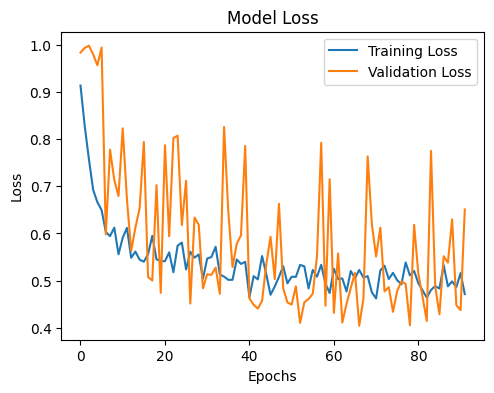

In [ ]:
# We plot the training and validation loss to ensure there is no overfitting or underfitting, and no vanishing or exploding gradients.

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

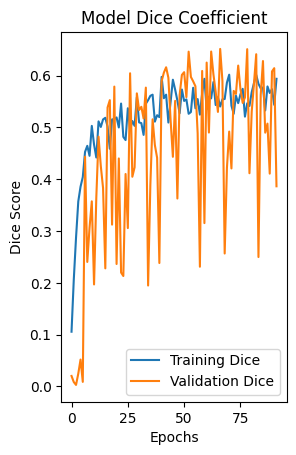

In [ ]:
# We also plot the dice coefficients for the training and validation datasets to assess model performance.

plt.subplot(1, 2, 2)
plt.plot(history.history['dice_coef'], label='Training Dice')
plt.plot(history.history['val_dice_coef'], label='Validation Dice')
plt.title('Model Dice Coefficient')
plt.xlabel('Epochs')
plt.ylabel('Dice Score')
plt.legend()

plt.show()

In [ ]:
# We evaluate the model on the validation data
# and calculate the DSC, Hausdorff distance and 95th percentile Hausdorff distance.
# This tells us how good our model currently is, and gives us an idea of
# how much improvement is required.

y_pred_probs = model.predict(X_val)
y_pred_bin = (y_pred_probs > 0.5).astype(int)
y_val_bin = y_val.astype(int)

global_dice = dc(y_pred_bin, y_val_bin)
print(f'Global Validation DSC: {global_dice:.4f}')

hd_list = []
hd95_list = []
slice_dice_list = []

for i in range(len(y_val_bin)):
    true_slice = y_val_bin[i]
    pred_slice = y_pred_bin[i]

    if np.sum(true_slice) == 0 and np.sum(pred_slice) == 0:
        slice_dice_list.append(1.0)
    else:
        slice_dice_list.append(dc(pred_slice, true_slice))

    if np.sum(true_slice) > 0 and np.sum(pred_slice) > 0:
        try:
            hd_val = hd(pred_slice, true_slice, voxelspacing = None)
            hd95_val = hd95(pred_slice, true_slice, voxelspacing = None)

            hd_list.append(hd_val)
            hd95_list.append(hd95_val)
        except Exception as e:
            pass

print(f'Average Slice-wise DSC: {np.mean(slice_dice_list):.4f}')

if hd_list:
    print(f'Average HD: {np.mean(hd_list):.2f} mm')
    print(f'Average HD95: {np.mean(hd95_list):.2f} mm')
    run_metrics = pd.DataFrame({'Global_Validation_DSC': [global_dice], 'Average_Slice-Wise_DSC': [np.mean(slice_dice_list)], 'Average_HD_in_mm': [np.mean(hd_list)], 'Average_HD95_in_mm': [np.mean(hd95_list)]})
    run_metrics.to_csv(f'{results_dir}/run_0{run_num}_performance.csv', index = False)
else:
    print('No matching positive slices found to calculate HD or HD95.')

3/3 ━━━━━━━━━━━━━━━━━━━━ 30s 7s/step
Global Validation DSC: 0.8704
Average Slice-wise DSC: 0.7201
Average HD: 10.72 mm
Average HD95: 7.23 mm


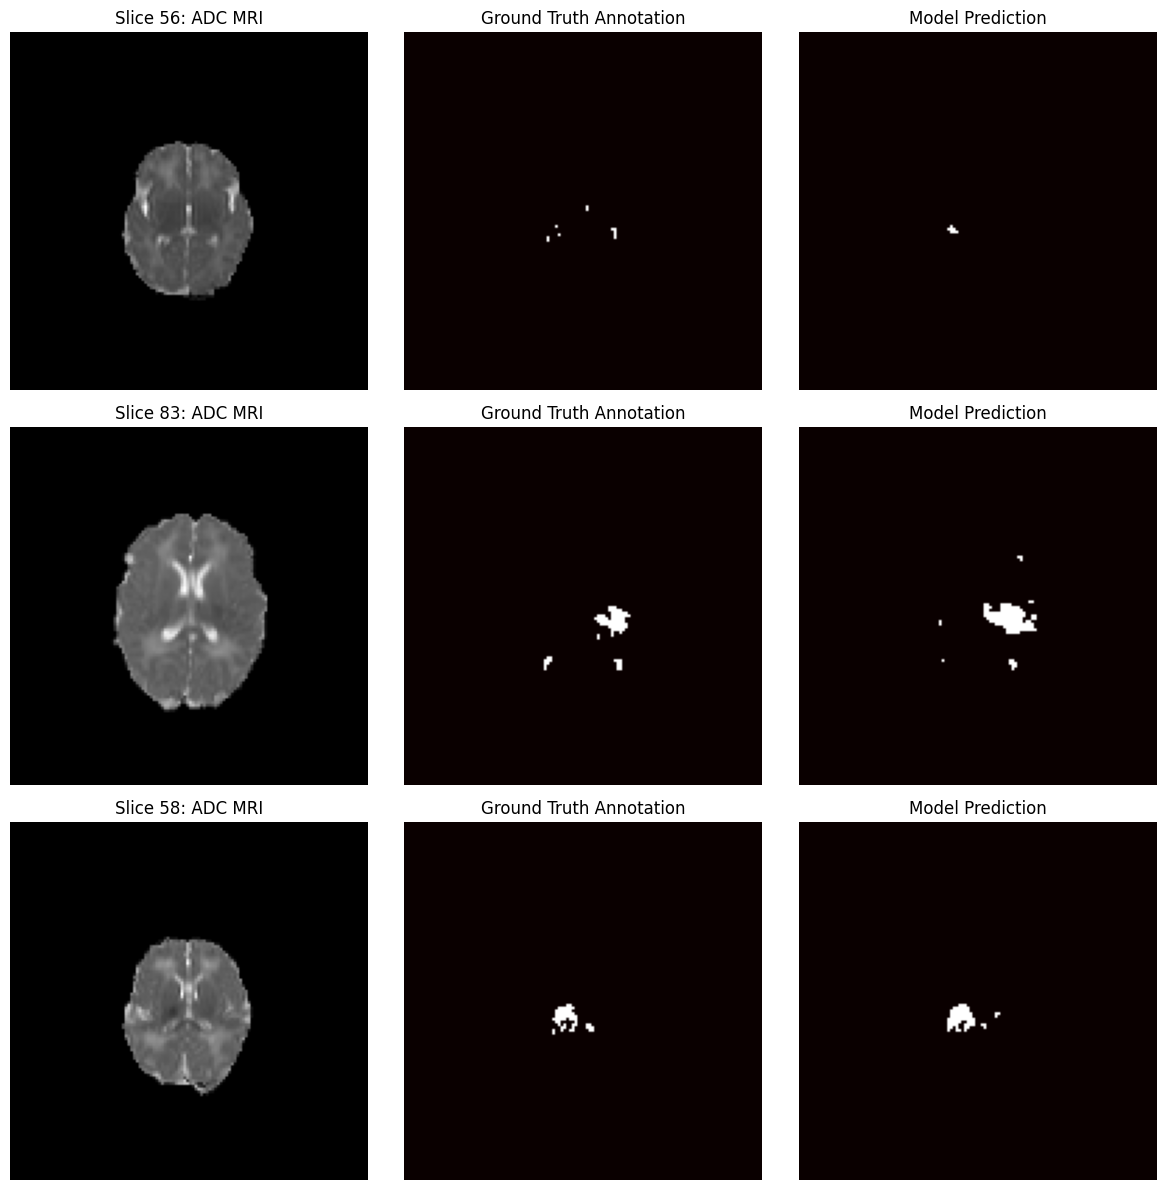

In [ ]:
# We also visualise the predicted binary masks to compare them with the ground truth.
# This allows us to visualise the model's performance at the task at hand, which performance metrics alone
# may not always capture completely.

positive_lesion_indices = [i for i in range(len(y_val)) if np.sum(y_val[i]) > 0]
sample_indices = random.sample(positive_lesion_indices, 3)

fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for i, idx in enumerate(sample_indices):
    mri_slice = X_val[idx, :, :, 0]
    true_mask = y_val[idx, :, :, 0]
    pred_mask = y_pred_bin[idx, :, :, 0]

    axes[i, 0].imshow(mri_slice, cmap = 'gray')
    axes[i, 0].set_title(f'Slice {idx}: ADC MRI')
    axes[i, 0].axis('off')

    axes[i, 1].imshow(true_mask, cmap = 'hot')
    axes[i, 1].set_title(f'Ground Truth Annotation')
    axes[i, 1].axis('off')

    axes[i, 2].imshow(pred_mask, cmap = 'hot')
    axes[i, 2].set_title(f'Model Prediction')
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()

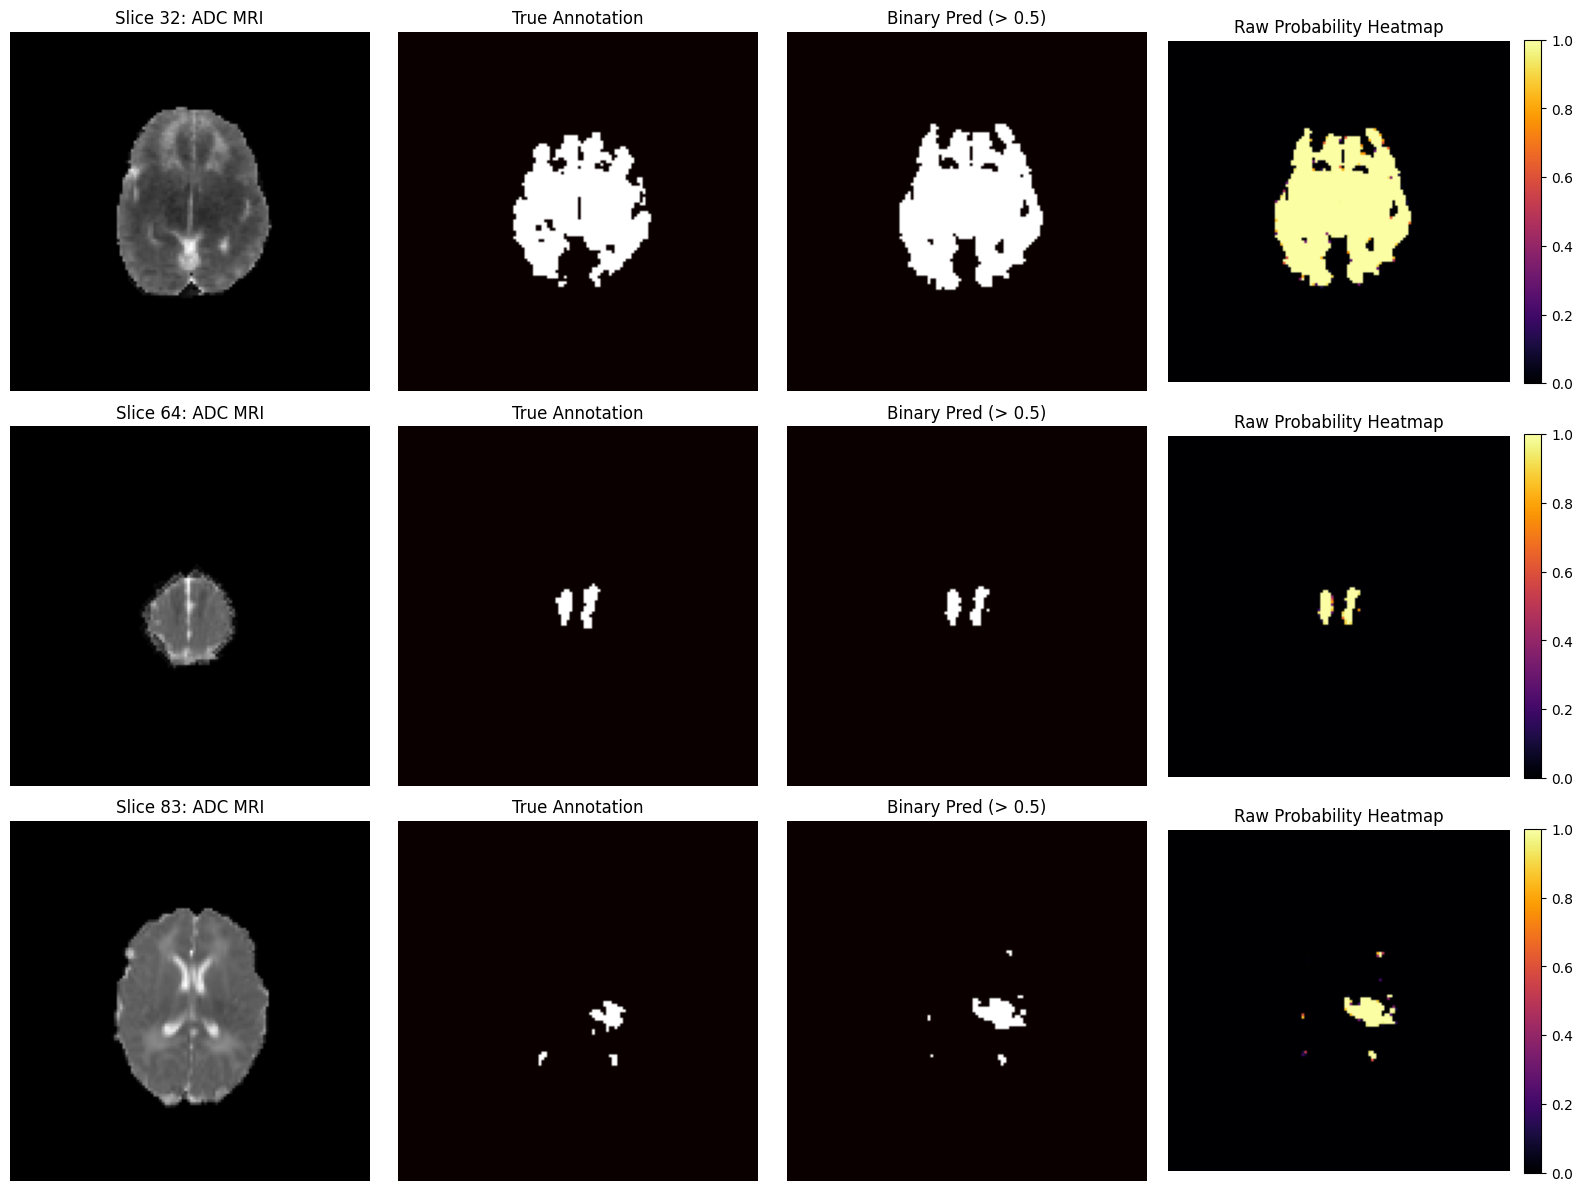

In [ ]:
# The following raw continuous probability heatmaps have been plotted to visualise the model's pixel-wise prediction confidence.
# We use these to determine if the model has reached its architectural limits, given the current hardware and data constraints.

positive_lesion_indices = [i for i in range(len(y_val)) if np.sum(y_val[i]) > 0]

sample_indices = random.sample(positive_lesion_indices, 3)

fig, axes = plt.subplots(3, 4, figsize=(16, 12))

for i, idx in enumerate(sample_indices):
    mri_slice = X_val[idx, :, :, 0]
    true_mask = y_val[idx, :, :, 0]
    pred_bin = y_pred_bin[idx, :, :, 0]
    pred_prob = y_pred_probs[idx, :, :, 0]

    axes[i, 0].imshow(mri_slice, cmap='gray')
    axes[i, 0].set_title(f"Slice {idx}: ADC MRI")
    axes[i, 0].axis('off')

    axes[i, 1].imshow(true_mask, cmap='hot')
    axes[i, 1].set_title("True Annotation")
    axes[i, 1].axis('off')

    axes[i, 2].imshow(pred_bin, cmap='hot')
    axes[i, 2].set_title("Binary Pred (> 0.5)")
    axes[i, 2].axis('off')

    im = axes[i, 3].imshow(pred_prob, cmap='inferno', vmin=0, vmax=1)
    axes[i, 3].set_title("Raw Probability Heatmap")
    axes[i, 3].axis('off')

    fig.colorbar(im, ax=axes[i, 3], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [ ]:
# The moment of truth. Having perfected our model as much as possible, we now bring out the final testing set.

final_model = keras.models.load_model(f'{results_dir}/run_8.keras', compile = False)

test_pred_probs = final_model.predict(X_test)
test_pred_bin = (test_pred_probs > 0.5).astype(np.float32)
y_test_f = y_test.astype(np.float32)

intersection_test = np.sum(y_test_f * test_pred_bin)
global_dsc_test = (2.0 * intersection_test) / (np.sum(y_test_f) + np.sum(test_pred_bin) + 1e-6)

hd_list_test = []
hd95_list_test = []
slice_dice_list_test = []

for i in range(len(test_pred_bin)):
    true_slice_test = y_test_f[i]
    pred_slice_test = test_pred_bin[i]

    if np.sum(true_slice_test) == 0 and np.sum(pred_slice_test) == 0:
        slice_dice_list_test.append(1.0)
    else:
        slice_dice_list_test.append(dc(pred_slice_test, true_slice_test))

    if np.sum(true_slice_test) > 0 and np.sum(pred_slice_test) > 0:
        try:
            hd_test = hd(pred_slice_test, true_slice_test, voxelspacing = None)
            hd95_test = hd95(pred_slice_test, true_slice_test, voxelspacing = None)

            hd_list_test.append(hd_test)
            hd95_list_test.append(hd95_test)
        except Exception as e:
            pass

print(f"Global Test DSC: {global_dsc_test:.4f}")
print(f'Average Slice-wise DSC: {np.mean(slice_dice_list_test):.4f}')

if hd_list_test:
    print(f'Average HD: {np.mean(hd_list_test):.2f} mm')
    print(f'Average HD95: {np.mean(hd95_list_test):.2f} mm')

    run_metrics_test = pd.DataFrame({
        'Global_Test_DSC': [global_dsc_test],
        'Average_Slice-Wise_DSC': [np.mean(slice_dice_list_test)],
        'Average_HD_in_mm': [np.mean(hd_list_test)],
        'Average_HD95_in_mm': [np.mean(hd95_list_test)]
    })
    run_metrics_test.to_csv(f'{results_dir}/Final_Test_Performance.csv', index = False)
    print(f"\nMetrics successfully saved to {results_dir}/Final_Test_Performance.csv")
else:
    print('No matching positive slices found to calculate HD or HD95.')

32/32 ━━━━━━━━━━━━━━━━━━━━ 733s 23s/step
Global Test DSC: 0.8294
Average Slice-wise DSC: 0.7064
Average HD: 11.55 mm
Average HD95: 8.00 mm

Metrics successfully saved to /content/drive/MyDrive/CSE602_Project_Results/Final_Test_Performance.csv


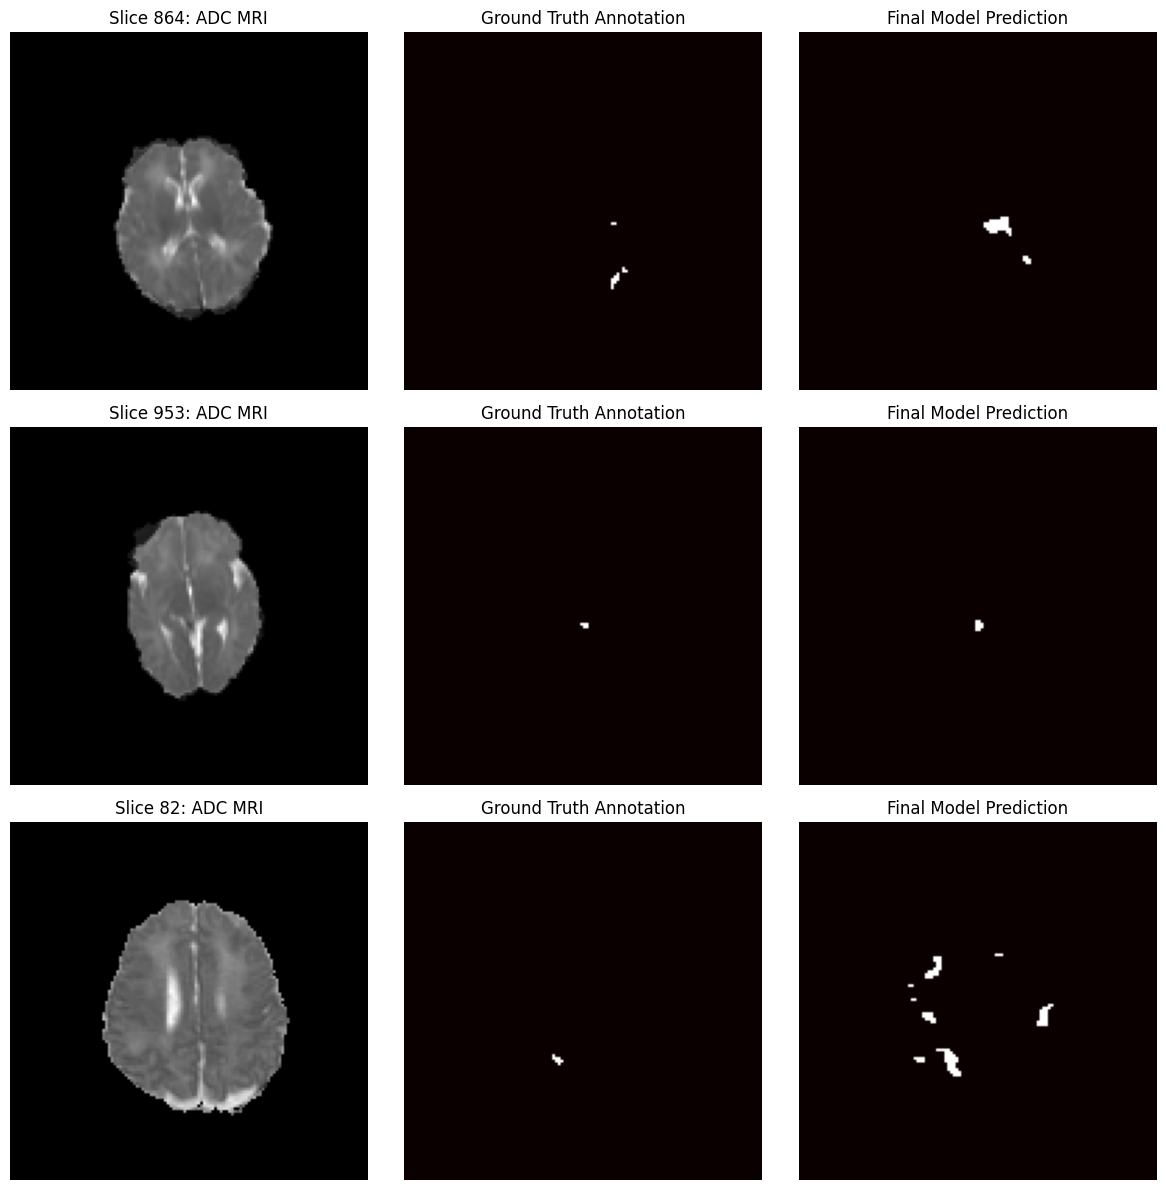

In [ ]:
# As we had done for the validation dataset, we plot the predicted binary masks as a visual comparison...

positive_lesion_indices = [i for i in range(len(y_test)) if np.sum(y_test[i]) > 0]
sample_indices = random.sample(positive_lesion_indices, 3)

fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for i, idx in enumerate(sample_indices):
    mri_slice = X_test[idx, :, :, 0]
    true_mask = y_test[idx, :, :, 0]
    pred_mask = test_pred_bin[idx, :, :, 0]

    axes[i, 0].imshow(mri_slice, cmap = 'gray')
    axes[i, 0].set_title(f'Slice {idx}: ADC MRI')
    axes[i, 0].axis('off')

    axes[i, 1].imshow(true_mask, cmap = 'hot')
    axes[i, 1].set_title(f'Ground Truth Annotation')
    axes[i, 1].axis('off')

    axes[i, 2].imshow(pred_mask, cmap = 'hot')
    axes[i, 2].set_title(f'Final Model Prediction')
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()

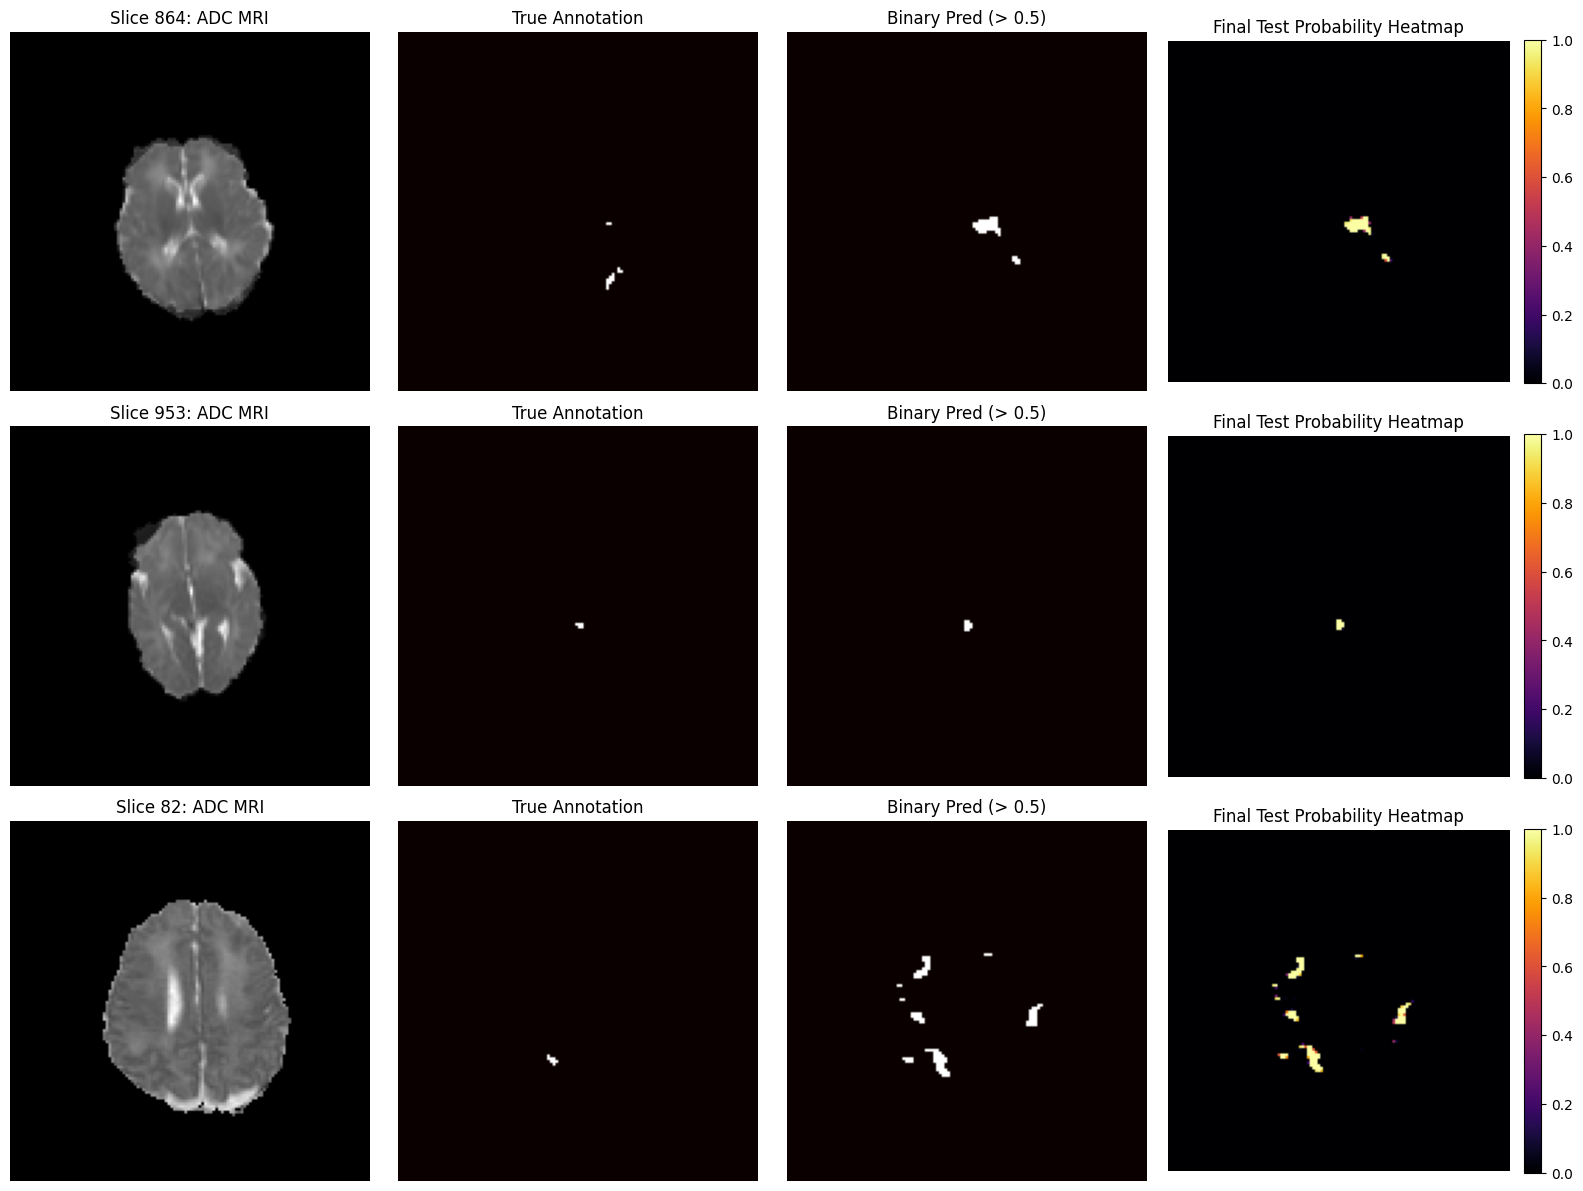

In [ ]:
#...along with the continuous probability heatmaps, as a visual representation of the model's confidence
# across the brain tissue.

fig, axes = plt.subplots(3, 4, figsize=(16, 12))

for i, idx in enumerate(sample_indices):
    mri_slice = X_test[idx, :, :, 0]
    true_mask = y_test[idx, :, :, 0]
    pred_bin = test_pred_bin[idx, :, :, 0]
    pred_prob = test_pred_probs[idx, :, :, 0]

    axes[i, 0].imshow(mri_slice, cmap = 'gray')
    axes[i, 0].set_title(f"Slice {idx}: ADC MRI")
    axes[i, 0].axis('off')

    axes[i, 1].imshow(true_mask, cmap = 'hot')
    axes[i, 1].set_title("True Annotation")
    axes[i, 1].axis('off')

    axes[i, 2].imshow(pred_bin, cmap='hot')
    axes[i, 2].set_title("Binary Pred (> 0.5)")
    axes[i, 2].axis('off')

    im = axes[i, 3].imshow(pred_prob, cmap='inferno', vmin=0, vmax=1)
    axes[i, 3].set_title("Final Test Probability Heatmap")
    axes[i, 3].axis('off')

    fig.colorbar(im, ax=axes[i, 3], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

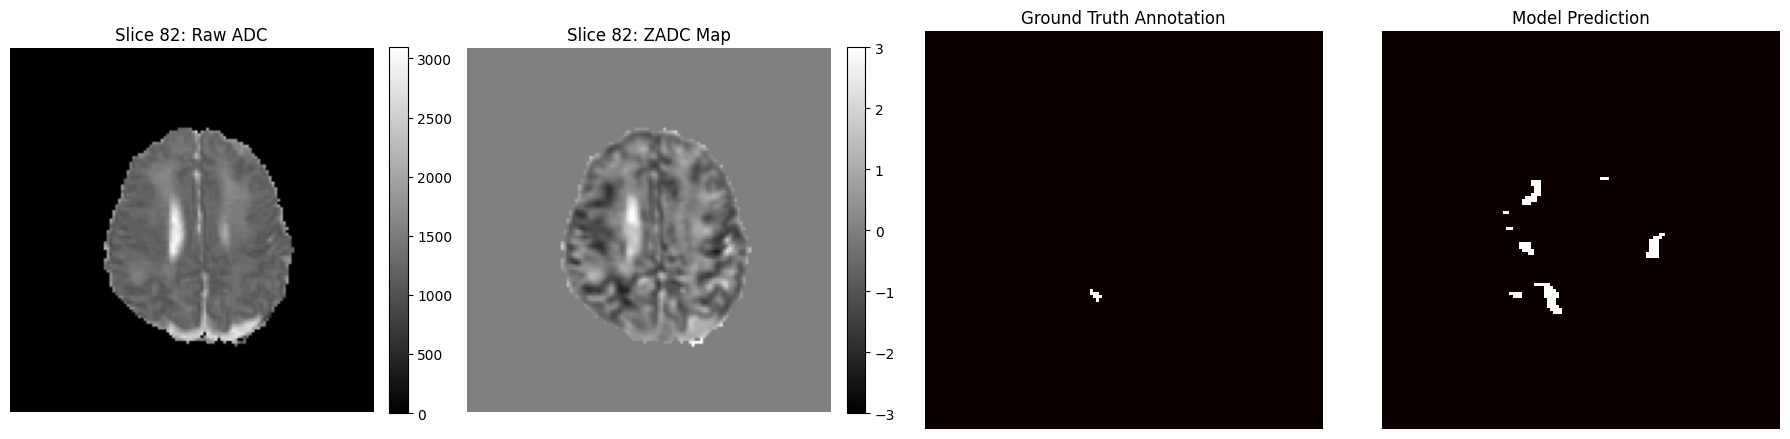

In [ ]:
# We compare the evidently problematic slice 82 with the ZADC maps in addition to the raw ADC maps.
# This could provide a better idea of what caused the model to get confused and hallucinate lesions where none were identified by the physician.

target_idx = 82

mri_adc = X_test[target_idx, :, :, 0]
mri_zadc = X_test[target_idx, :, :, 1]
true_mask = y_test[target_idx, :, :, 0]
pred_mask = test_pred_bin[target_idx, :, :, 0]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

im0 = axes[0].imshow(mri_adc, cmap='gray')
axes[0].set_title(f'Slice {target_idx}: Raw ADC')
axes[0].axis('off')
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(mri_zadc, cmap='gray', vmin = -3, vmax = 3)
axes[1].set_title(f'Slice {target_idx}: ZADC Map')
axes[1].axis('off')
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

axes[2].imshow(true_mask, cmap='hot')
axes[2].set_title('Ground Truth Annotation')
axes[2].axis('off')

axes[3].imshow(pred_mask, cmap='hot')
axes[3].set_title('Model Prediction')
axes[3].axis('off')

plt.tight_layout()
plt.show()